In [25]:
from ipywidgets import FileUpload
import io
import numpy as np
from matplotlib import pyplot as plt

upload = FileUpload(accept='image/*', multiple=False)
display(upload)


FileUpload(value=(), accept='image/*', description='Upload')

In [29]:
def read_image(upload_widget):
    if len(upload_widget.value) == 0:
        print("Silakan upload gambar terlebih dahulu.")
        return None

    # Ambil file pertama dari tuple
    file_info = upload_widget.value[0]

    image_data = plt.imread(io.BytesIO(file_info['content']))
    if image_data.dtype == np.float32 or image_data.dtype == np.float64:
        image_data = (image_data * 255).astype(np.uint8)
    return image_data

img = read_image(upload)



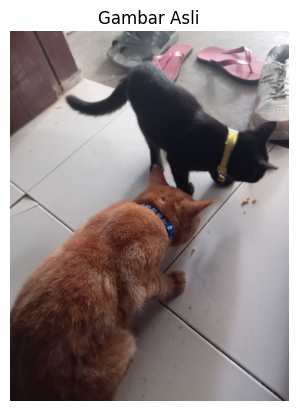

In [30]:
# Cell 2: Membaca gambar yang diupload dan menampilkannya
if len(upload.value) > 0:  # Mengecek apakah ada file yang diupload
    image_data = read_image(upload)  # Panggil fungsi untuk membaca gambar
    
    if image_data is not None:
        plt.imshow(image_data)
        plt.axis('off')  # Menghilangkan axis
        plt.title("Gambar Asli")
        plt.show()  # Menampilkan gambar yang diupload
    else:
        print("Gagal memuat gambar.")
else:
    print("Silakan upload gambar terlebih dahulu.")


In [31]:
def to_binary_from_image(img, threshold=128):
    height = len(img)
    width = len(img[0])
    binary_img = []

    for i in range(height):
        row = []
        for j in range(width):
            pixel = img[i][j]
            if len(pixel) >= 3:
                r, g, b = pixel[:3]
                gray = int((int(r) + int(g) + int(b)) / 3)
            else:
                gray = int(pixel)
            row.append(255 if gray >= threshold else 0)
        binary_img.append(row)

    return binary_img


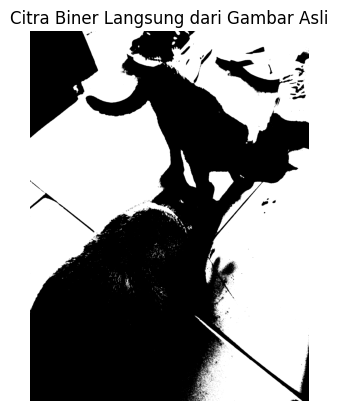

In [32]:
binary_direct = to_binary_from_image(img)

import numpy as np
binary_array = np.array(binary_direct, dtype=np.uint8)

plt.imshow(binary_array, cmap='gray')
plt.title("Citra Biner Langsung dari Gambar Asli")
plt.axis('off')
plt.show()
